In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='Species')

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("Dataset shape:", X.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

Dataset shape: (150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model training completed!")

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Training data: (120, 4)
Testing data: (30, 4)
Model training completed!
Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Accuracy: 96.67 %
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



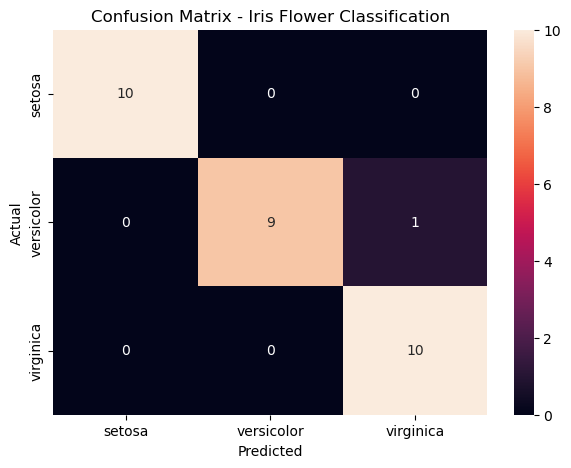

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Iris Flower Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

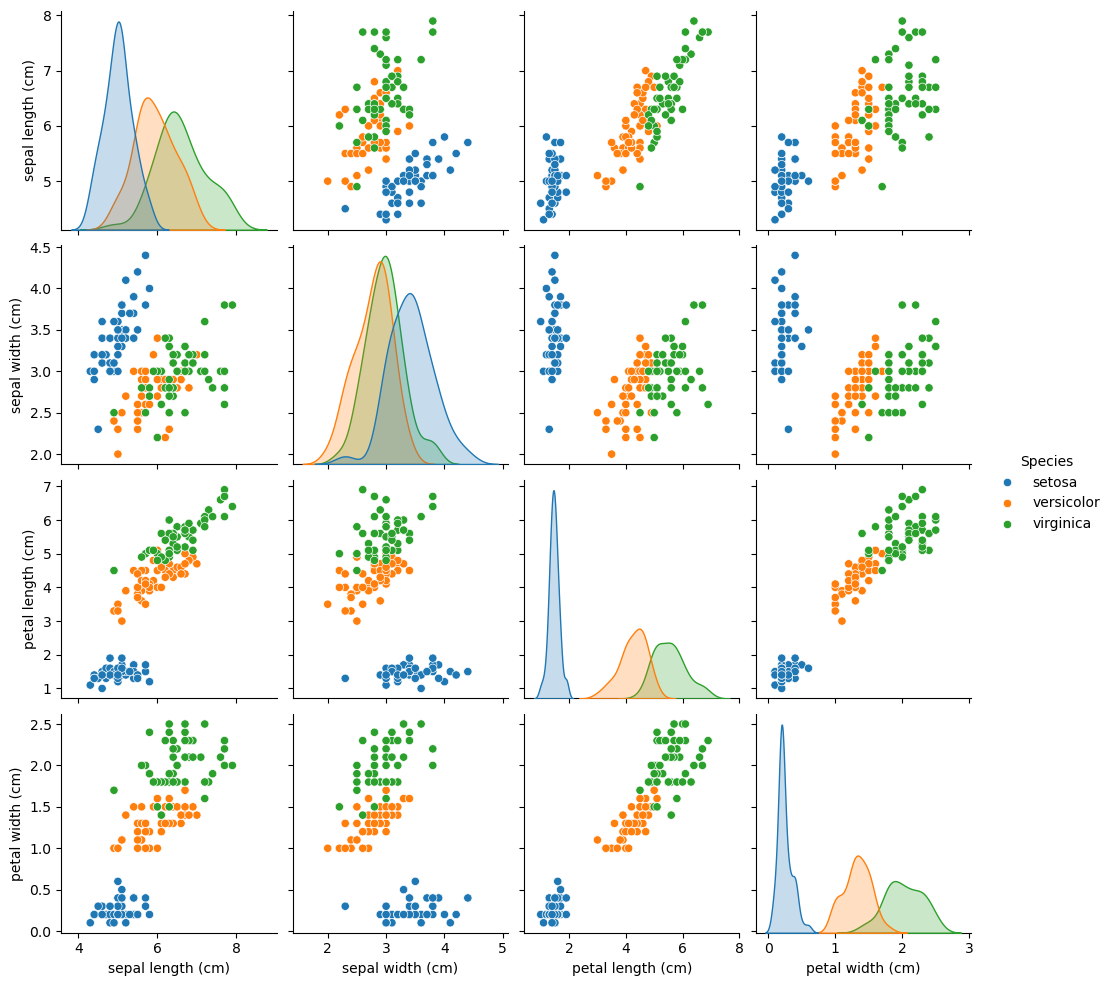

In [14]:
sns.pairplot(
    pd.concat([X, y.replace(dict(enumerate(iris.target_names)))], axis=1),
    hue='Species'
)

plt.show()

In [16]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

prediction = model.predict(sample)

print("Predicted flower:", iris.target_names[prediction[0]])

Predicted flower: setosa


## Conclusion

The Iris Flower Classification project uses machine learning to classify iris flowers into three species: Setosa, Versicolor, and Virginica.

The Iris dataset was loaded and divided into training and testing sets. Logistic Regression was trained using the four flower measurements: sepal length, sepal width, petal length, and petal width.

The trained model was evaluated using accuracy, classification report, and confusion matrix. The results demonstrate that machine learning can effectively classify iris flower species based on their physical measurements.